In [1]:

%reload_ext autoreload
%autoreload 2
import os, re
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from neuro_py.raw import preprocessing as prpc 

from pathlib import Path
from src.preprocess import (
    PreprocessConfig,
    prepare_chanmap,
    run_preprocess_session,
    select_paths_with_gui,
    show_chanmap,
)
from src.preprocess.io import copy_results_to_basepath


In [2]:
def extract_datetime(path):
    m = re.search(r'(\d{6}_\d{6})', str(path))
    if m:
        return datetime.strptime(m.group(1), "%y%m%d_%H%M%S")
    return datetime.min 

In [3]:
use_gui = False
manual_basepath = "/local/workdir/ys2375/data/ayadataB4/data/awake_ripples_project/Pisco/pisco_day9"
basePath, basename, local_output_dir, xml_path = select_paths_with_gui(
    use_gui=use_gui,
    manual_basepath=manual_basepath,
    initial_drive=r'S:\\',
    # local_root=Path('/fs/cbsuruizfs1/storage/ys2375/sorting_temp'),
    local_root=Path.cwd() / 'sorting_temp',
)


if basePath:
    print(f"Selected folder: {basePath}")
    dataDirs = sorted([p for p in basePath.iterdir() if p.is_dir()], key=extract_datetime)
    display(dataDirs)
else:
    print("No folder selected")
    basePath = None

Selected folder: /fs/ayadata2-afr77.nbb.cornell.edu/volume4/ayadataB4/data/awake_ripples_project/Pisco/pisco_day9


[PosixPath('/fs/ayadata2-afr77.nbb.cornell.edu/volume4/ayadataB4/data/awake_ripples_project/Pisco/pisco_day9/pisco_presleep_260429_111251')]

In [4]:
dataDir = dataDirs[0]
dat_files = sorted(dataDir.glob('*.dat'))
if not dat_files:
    raise FileNotFoundError(f'No .dat files found in {dataDir}')
dataPath2Cut = dat_files[0]
dataPath2Cut

PosixPath('/fs/ayadata2-afr77.nbb.cornell.edu/volume4/ayadataB4/data/awake_ripples_project/Pisco/pisco_day9/pisco_presleep_260429_111251/amplifier.dat')

In [5]:
n_channels_amplifier = 256  # number of channels in amplifier.dat; change if yours differs      
fs = 20_000                     # sampling rate [Hz]; change if yours differs

# --- compute n_samples from amplifier.dat size ---
bytes_per_sample = np.dtype(np.int16).itemsize  # amplifier.dat is int16 -> 2 bytes
n_samples = os.path.getsize(dataPath2Cut) // (n_channels_amplifier * bytes_per_sample)
seconds = n_samples / fs
m, s = divmod(int(seconds), 60)
ms = int((seconds - int(seconds)) * 1000)
print(f"n_samples: {n_samples}, duration: {m} min {s} sec {ms} ms")

n_samples: 180950144, duration: 150 min 47 sec 507 ms


In [6]:
# --- build cut_intervals ---
# NOTE: interval is half-open [start, end)
last_start = max(0, n_samples - int(600 * fs))  # clamp to 0 if shorter than 10s
cut_intervals = [(last_start, n_samples)]
print(f"cut_intervals: {cut_intervals}")
for label, samples in zip(["start", "end"], [last_start, n_samples]):
    secs = samples / fs
    m, s = divmod(int(secs), 60)
    ms = int((secs - int(secs)) * 1000)
    print(f"{label}: {m} min {s} sec {ms} ms")

cut_intervals: [(168950144, 180950144)]
start: 140 min 47 sec 507 ms
end: 150 min 47 sec 507 ms


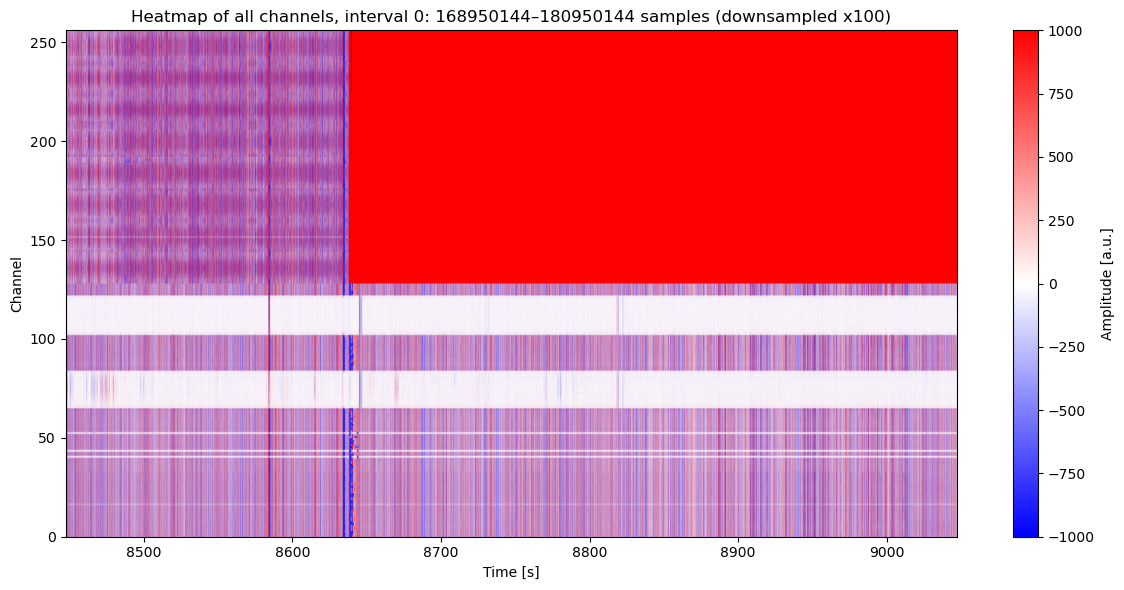

In [7]:
# Load with memory mapping 
data = np.memmap(dataPath2Cut, dtype=np.int16, mode="r")
n_samples = data.size // n_channels_amplifier
data = data.reshape((n_samples, n_channels_amplifier))

# Plot all channels in each cut interval as a heatmap
for i, (start, end) in enumerate(cut_intervals):
    sig = data[start:end, :]     # shape: (samples, channels)
    t = np.arange(start, end) / fs  # time axis in seconds

    # Downsample for faster plotting (every 10th sample)
    downsample_factor = 100
    sig_downsampled = sig[::downsample_factor, :]
    t_downsampled = t[::downsample_factor]

    plt.figure(figsize=(12, 6))
    # Transpose so that rows=channels, cols=time
    plt.imshow(sig_downsampled.T, aspect="auto", vmin=-1000, vmax=1000,
               extent=[t_downsampled[0], t_downsampled[-1], 0, n_channels_amplifier],
               origin="lower", cmap="bwr")
    plt.colorbar(label="Amplitude [a.u.]")
    plt.xlabel("Time [s]")
    plt.ylabel("Channel")
    plt.title(f"Heatmap of all channels, interval {i}: {start}–{end} samples (downsampled x{downsample_factor})")
    plt.tight_layout()
    plt.show()

In [8]:
prpc.cut_artifacts_intan(
    folder_name=str(dataDir),
    n_channels_amplifier=n_channels_amplifier,
    cut_intervals=cut_intervals,
)

Processing amplifier.dat file...
Processing auxiliary.dat file...
Processing digitalin.dat file...
Processing time.dat file...
